Original Data:
 [[ 4 11]
 [ 8  4]
 [13  5]
 [ 7 14]]
PCA Transformed Data:
 [[ 4.30518692]
 [-3.73612869]
 [-5.69282771]
 [ 5.12376947]]


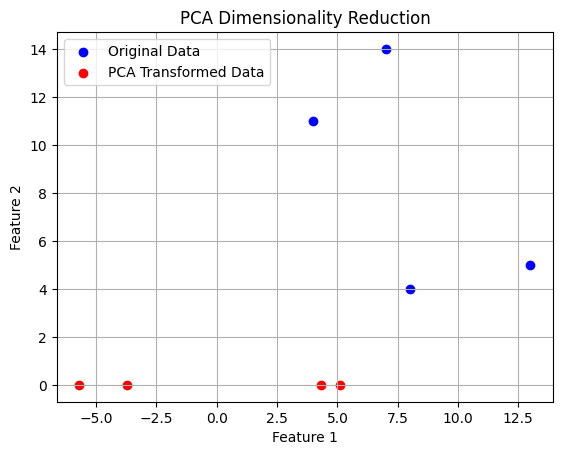

In [11]:
import numpy as np
from sklearn.decomposition import PCA
X = np.array([[4,11],[8,4],[13,5],[7,14]])
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)
print("Original Data:\n", X)
print("PCA Transformed Data:\n", X_pca)
#Visualization
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(X[:,0], X[:,1], color='blue', label='Original Data')
plt.scatter(X_pca[:,0], np.zeros_like(X_pca[:,0]), color='red', label='PCA Transformed Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA Dimensionality Reduction')
plt.legend()
plt.grid()
plt.show()

Mean: [8.  8.5]
Principal Component Vector: [-0.55738997  0.83025082]
Explained Variance: 30.384864324004706


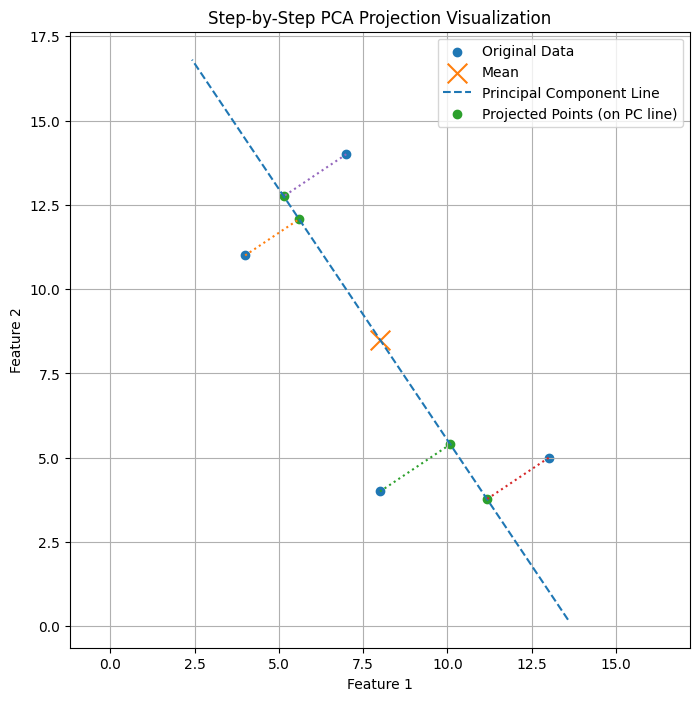


PCA 1D Transformed Values:
[[ 4.30518692]
 [-3.73612869]
 [-5.69282771]
 [ 5.12376947]]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Original Data
# -----------------------------
X = np.array([
    [4,11],
    [8,4],
    [13,5],
    [7,14]
])

# -----------------------------
# Step 1: Mean Centering
# -----------------------------
mean = np.mean(X, axis=0)
X_centered = X - mean

# -----------------------------
# Step 2: PCA Fit
# -----------------------------
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

pc_vector = pca.components_[0]     # Principal Component direction
variance = pca.explained_variance_[0]

print("Mean:", mean)
print("Principal Component Vector:", pc_vector)
print("Explained Variance:", variance)

# -----------------------------
# Step 3: Projection Manually
# -----------------------------
# projection scalar = dot(centered_point, PC_vector)
proj_scalars = X_centered @ pc_vector

# projected points in 2D space
proj_points = np.outer(proj_scalars, pc_vector) + mean

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(8,8))

# Original points
plt.scatter(X[:,0], X[:,1], label="Original Data")

# Mean point
plt.scatter(mean[0], mean[1], marker='x', s=200, label="Mean")

# PC Line (Fit Line)
t = np.linspace(-10, 10, 100)
pc_line = mean + np.outer(t, pc_vector)
plt.plot(pc_line[:,0], pc_line[:,1], linestyle='--', label="Principal Component Line")

# Projection arrows (step visualization)
for i in range(len(X)):
    plt.plot(
        [X[i,0], proj_points[i,0]],
        [X[i,1], proj_points[i,1]],
        linestyle=':'
    )

# Projected points on PC line
plt.scatter(proj_points[:,0], proj_points[:,1], label="Projected Points (on PC line)")

plt.title("Step-by-Step PCA Projection Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

# -----------------------------
# Final 1D PCA Values
# -----------------------------
print("\nPCA 1D Transformed Values:")
print(X_pca)


Proportion of Variance Captured by Each Principal Component:
PC1: 0.8065
PC2: 0.1935


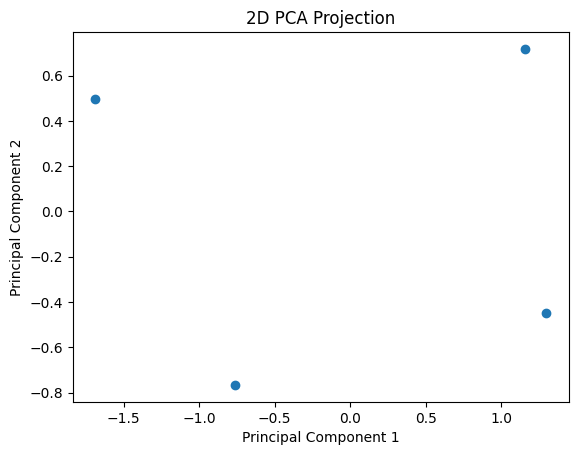

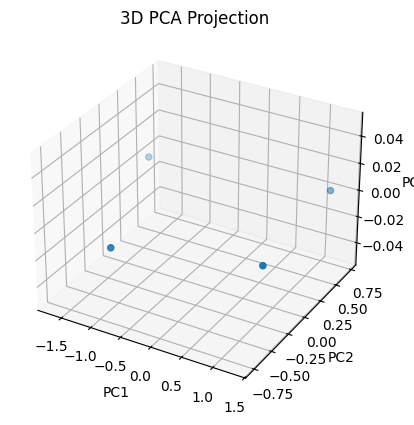

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

X1 = [4, 8, 13, 7]
X2 = [11, 4, 5, 14]

X = np.array(list(zip(X1, X2)))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Proportion of Variance Captured by Each Principal Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection")
plt.show()

pca_3d = PCA(n_components=2)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], np.zeros(len(X_3d)))
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
plt.show()